In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [4]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [5]:
df = pd.read_csv("/content/bangladesh_student_performance.csv")
df.head()

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94


In [6]:
df.shape

(2018, 16)

In [7]:
df.isnull().sum()

,0
date,0
gender,0
age,0
address,0
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,0
F_Job,0


In [8]:
df.columns

Index(['date', 'gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu',
       'F_Edu', 'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB


#EDA

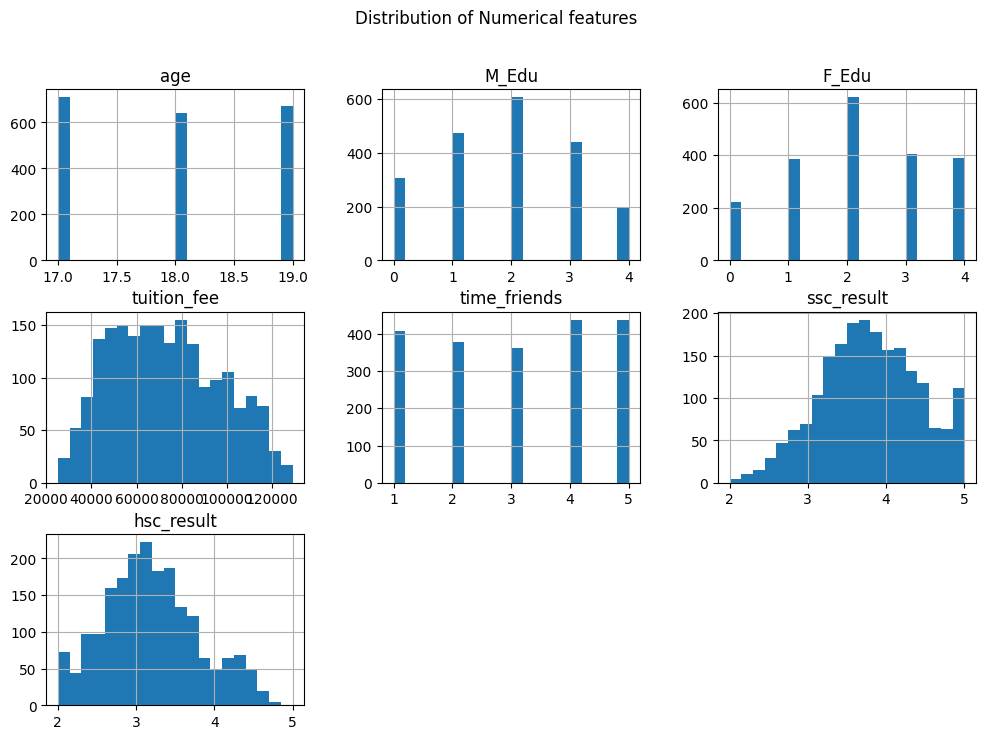

In [10]:
df.hist(figsize = (12,8), bins = 20)

plt.suptitle("Distribution of Numerical features")
plt.show()

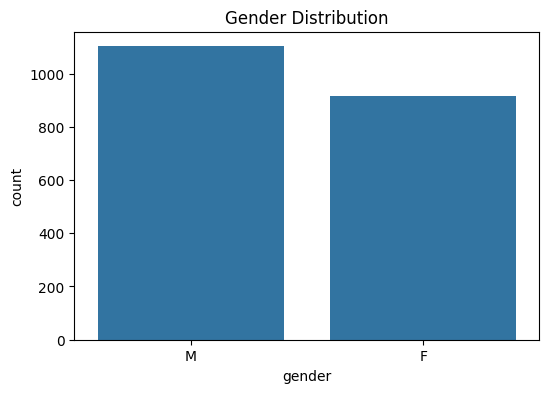

In [11]:
# Gender Distribution

plt.figure(figsize = (6,4))

sns.countplot(
    data = df,
    x = "gender"
)

plt.title("Gender Distribution")
plt.show()

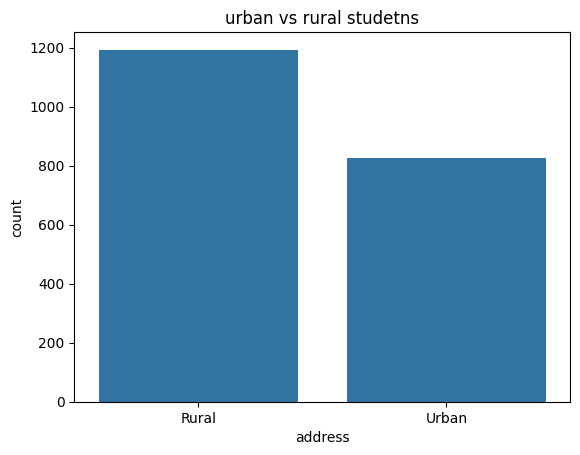

In [12]:
# plt.figure(figsize = (6,4) )

sns.countplot(
    data = df,
    x = "address"
)

plt.title("urban vs rural studetns")
plt.show()

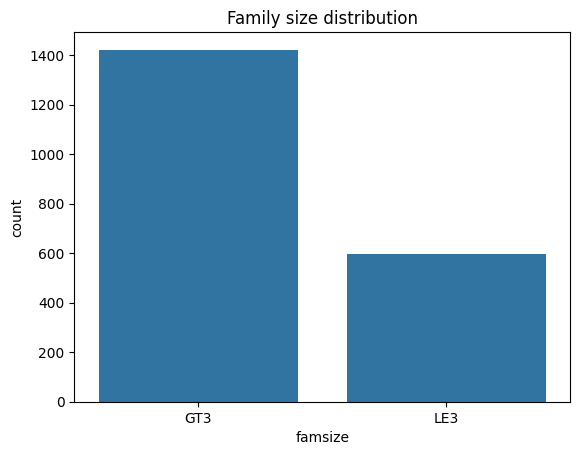

In [13]:
sns.countplot(
    data = df,
    x = "famsize"
)

plt.title("Family size distribution")
plt.show()

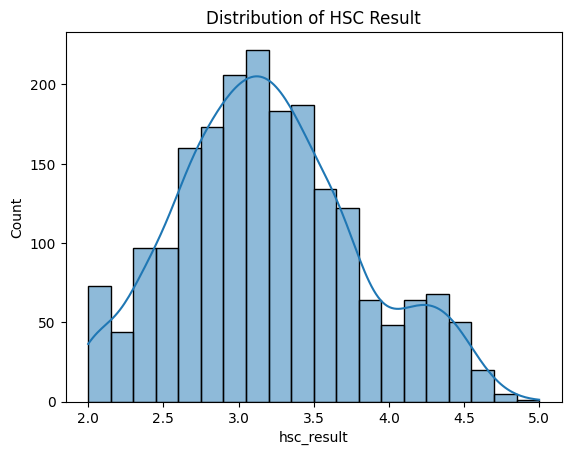

In [14]:
sns.histplot(
    df['hsc_result'],
    bins = 20,
    kde= True

)
plt.title("Distribution of HSC Result")
plt.show()

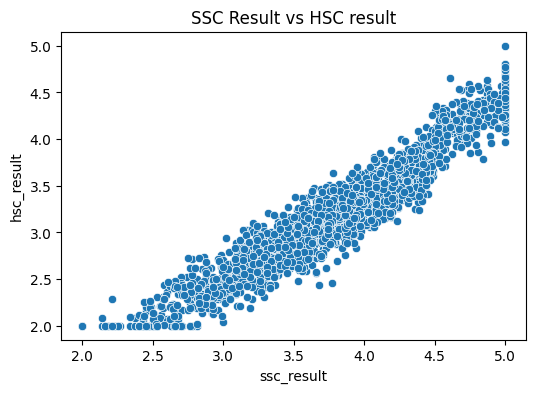

In [15]:
# SSC VS HSC

plt.figure(figsize = (6,4) )

sns.scatterplot(
    data = df ,
    x = "ssc_result",
    y = "hsc_result"
)

plt.title("SSC Result vs HSC result")
plt.show()

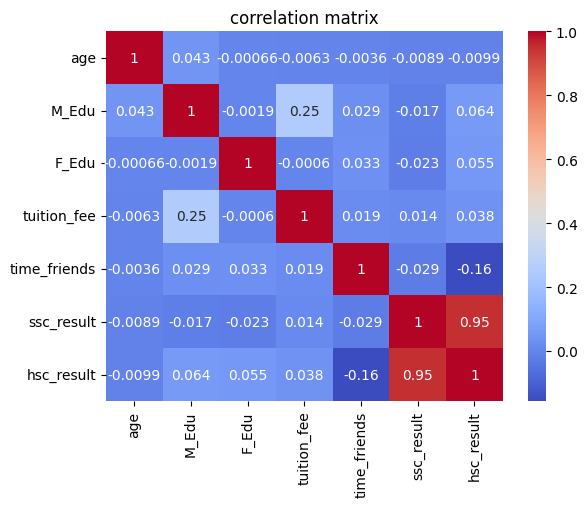

In [16]:
# co-relation heatmap

sns.heatmap(
    df.select_dtypes(include = np.number).corr(),
    annot= True,
    cmap = 'coolwarm'
)
plt.title("correlation matrix")
plt.show()

#Feature and Traget

In [17]:
X = df.drop(columns = ['hsc_result','date'])
y = df['hsc_result']

In [18]:
X

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
0,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22
1,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47
2,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32
3,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57
4,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57
2014,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05
2015,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93
2016,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34


In [19]:
y

,hsc_result
0,3.72
1,2.62
2,2.56
3,4.17
4,3.94
...,...
2013,3.18
2014,3.13
2015,3.15
2016,2.83


#Pipe  Line

Numerical and catagorical Feature ber kora

In [20]:
numerical_feature = X.select_dtypes(
    include = ['int64' , 'float64']
).columns

In [21]:
numerical_feature

Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')

In [22]:
catagorical_features = X.select_dtypes(
    include = ['object']
).columns

In [23]:
catagorical_features

Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object')

In [24]:
num_transforman = Pipeline(
    steps = [
        ('imouter', SimpleImputer(strategy = 'median')),
        ('scaler' , StandardScaler())
    ]
)

In [25]:
num_transforman

Pipeline(steps=[('imouter', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [26]:
cat_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder' , OneHotEncoder(handle_unknown='ignore'))
    ]

)

In [27]:
cat_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [28]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num",num_transforman,numerical_feature),
        ("cat",cat_transformer,catagorical_features)
    ]
)

In [29]:
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imouter',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])

In [30]:
X_train, X_test , y_train, y_test = train_test_split(
    X,y, test_size = 0.20 , random_state = 42
)

In [31]:
X_train

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19,Rural,LE3,Together,2,2,Other,Services,No,No,49318,3,4.95
1381,M,17,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032,5,2.68
240,F,17,Urban,GT3,Together,4,3,Other,Services,No,No,116230,4,3.75
1646,M,18,Urban,LE3,Apart,2,1,Other,Business,No,No,79334,3,3.70
1460,M,18,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18,Rural,GT3,Together,2,2,At_home,Health,No,No,50003,1,3.83
1294,F,19,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895,2,3.30
860,F,19,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576,1,5.00
1459,F,18,Rural,GT3,Together,2,4,Other,Services,No,No,45830,1,4.42


In [32]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743,1,3.88
526,M,19,Rural,GT3,Together,4,3,At_home,Business,No,No,58678,5,4.36
393,F,18,Urban,GT3,Together,2,1,Services,Services,No,No,115832,3,4.47
1789,M,17,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781,1,4.43
433,M,19,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345,4,3.47
693,M,19,Urban,GT3,Together,1,2,Health,Business,No,No,85346,4,2.96
1494,F,18,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638,1,3.76
921,M,19,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804,2,4.18


#Linear Regression

In [33]:
lr_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imouter',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [34]:
lr_pipeline.predict(X_test)

array([3.22669684, 3.75113021, 3.83030552, 4.00812429, 3.90813125,
       3.33268499, 3.98238917, 2.54100569, 1.97989523, 3.27136765,
       3.67618639, 2.91974684, 3.23916997, 4.27745666, 3.03796909,
       2.67666797, 3.71635128, 3.45139645, 2.80448432, 2.96032266,
       2.82279738, 3.20360175, 2.99955789, 3.21756623, 1.89824069,
       2.58427455, 3.18535317, 3.82782921, 3.08736856, 3.94791665,
       2.41118168, 3.94402908, 4.31536621, 2.56485679, 3.1906842 ,
       3.26168549, 2.76183262, 3.65744712, 2.48538661, 2.6087985 ,
       3.07530752, 2.97249903, 3.73751782, 2.76766138, 2.17550874,
       3.06821563, 2.62014172, 2.6103055 , 4.03595945, 3.26038622,
       3.07496713, 3.45228036, 4.23442796, 3.63506638, 3.07127632,
       3.19967274, 3.29198851, 2.67393509, 3.81513176, 2.68699449,
       3.00552459, 2.76655742, 2.49090392, 4.43182742, 2.56047125,
       3.21025981, 3.96789734, 2.66949768, 3.03343159, 3.21841769,
       3.03009111, 2.722802  , 2.61470787, 3.63521455, 3.08131

#SGD

In [35]:
ETA = 0.001
MAX_ITER = 3000
ALPHA = 0.0001


sgd_pipeline = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('model', SGDRegressor(
           loss = "squared_error",
            penalty = 'l2',
            alpha = ALPHA,
            learning_rate = 'constant',
            eta0= ETA,
            max_iter = MAX_ITER,
            random_state = 42
        ))
    ]
)


sgd_pipeline.fit(X_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imouter',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'M_Edu', 'F_Edu', 'tuition_fee', 'time_friends', 'ssc_result'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'address', 'famsize', 'Pstatus', 'M_Job', 'F_Job',
       'relationship', 'smoker'],
      dtype='object'))])),
                ('model',
                 SGDRegressor(eta0=0.001, learning_rate='constant',
                              max_iter=3000, random_state=42))])

In [37]:
#Evaluation Function
def evaluate(model,name):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  print(f"\n{name}")
  print("-"*40)


  print("Train R2 :", round(r2_score(y_train , train_pred),4))
  print("Test R2 :", round(r2_score(y_test , test_pred),4))
  print("RMSE    :", round(np.sqrt(mean_squared_error(y_test, test_pred)),4))
  print("MSR     :", round(mean_squared_error(y_test, test_pred),4))

  return(
      r2_score(y_test , test_pred),
      np.sqrt(mean_squared_error(y_test , test_pred)),
      mean_absolute_error(y_test , test_pred)
  )

In [38]:
lr_r2 , lr_rmse , lr_mase = evaluate(
    lr_pipeline,
    "Liear Regression"
)


Liear Regression
----------------------------------------
Train R2 : 0.9466
Test R2 : 0.9459
RMSE    : 0.1424
MSR     : 0.0203


In [39]:
sgd_r2 , sgd_rmse , sgd_mase = evaluate(
    sgd_pipeline,
    'SGD regressor'
)


SGD regressor
----------------------------------------
Train R2 : 0.9447
Test R2 : 0.9453
RMSE    : 0.1432
MSR     : 0.0205


#Cross validation

In [41]:
cv_scores =  cross_val_score(
    lr_pipeline,
    X,
    y,
    cv = 5,
    scoring = "r2"
)


print("Score" , cv_scores)
print("Average cv 42", cv_scores.mean())

Score [0.94815437 0.95301409 0.93902546 0.94315463 0.94180106]
Average cv 42 0.9450299231558873


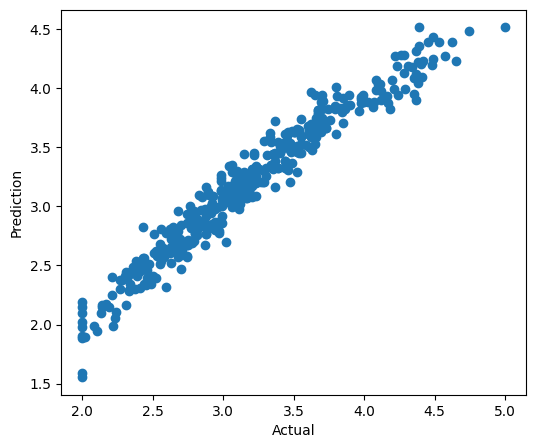

In [44]:
# actual vs predicted

y_pred = lr_pipeline.predict(X_test)
plt.figure(figsize = (6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Prediction")

plt.show()